In [108]:
import pandas as pd
import matplotlib.pyplot as plt
from funciones import clean_genres, get_imdb_info

pd.set_option("display.float_format", "{:.2f}".format)

In [79]:
# 1. carga de TMDB dataset
df = pd.read_csv("tmdb_5000_movies.csv")
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,7,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,8,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",44,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6,2124


In [80]:
df.shape

(4803, 20)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [82]:
# 2. Limpieza inicial dataset TMDB
df = df.drop(columns=["homepage", "tagline"], errors="ignore")
df = df.drop_duplicates()
df = df.dropna(subset=["overview","release_date", "runtime"])

In [83]:
df.shape

(4799, 18)

In [84]:
# 3. Limpieza de géneros 
df["genres"] = df["genres"].apply(clean_genres)

df_genres = df.explode("genres") # para separar listas en filas

df_genres = df_genres.dropna(subset=["genres"])

df_genres = df_genres.reset_index(drop=True)

df_genres.head()

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,title,vote_average,vote_count
0,237000000,Action,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Avatar,7,11800
1,237000000,Adventure,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Avatar,7,11800
2,237000000,Fantasy,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Avatar,7,11800
3,237000000,Science Fiction,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Avatar,7,11800
4,300000000,Adventure,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Pirates of the Caribbean: At World's End,7,4500


In [ ]:
# 4. Análisis EDA de TMDB
# 4.1. Géneros más frecuentes
df_genres["genres"].value_counts().head(10)

genres
Drama              2296
Comedy             1722
Thriller           1274
Action             1154
Romance             894
Adventure           790
Crime               696
Science Fiction     535
Horror              519
Family              513
Name: count, dtype: int64

Resultados. Los géneros más frecuentes son:

   - Drama → 2296

   - Comedy → 1722

   - Thriller → 1274

Insight inicial: 

- Drama y Comedy dominan el dataset. Posiblemente porque sean los géneros más baratos de producir.
    
- Géneros como Horror o Science Fiction tienen menor presencia

Esto solo nos da un contexto inicial de qué géneros son mucho más frecuentes en la industria del cine o especificamente en el TMDB dataset.

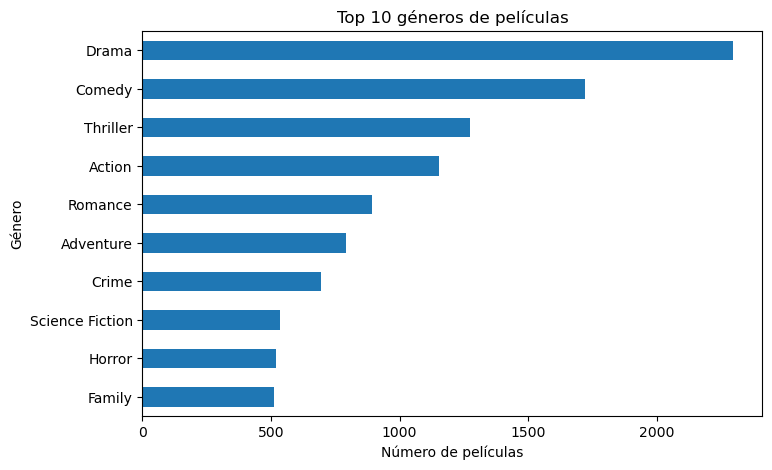

In [135]:
df_genres["genres"].value_counts().head(10).sort_values().plot(
    kind="barh",
    figsize=(8,5),
    title="Top 10 géneros de películas"
)
plt.xlabel("Número de películas")
plt.ylabel("Género")
plt.show()

In [ ]:
# 4.2 Valoración por género (vote_average)
# para responder: qué generos están mejor valorados(hipótesis 2)
df_genres.groupby("genres")["vote_average"].mean().sort_values(ascending=False)

genres
History            6.719797
War                6.713889
Drama              6.388197
Music              6.355676
Foreign            6.352941
Animation          6.341453
Documentary        6.285185
Crime              6.274138
Romance            6.207718
Mystery            6.183908
Western            6.178049
Adventure          6.156962
Fantasy            6.096698
Family             6.029630
Thriller           6.010989
Science Fiction    6.005607
Action             5.989515
Comedy             5.945587
TV Movie           5.662500
Horror             5.626590
Name: vote_average, dtype: float64

Tras calcular la valoración media de las peliculas de cada género se ha tenido el siguiente resultado:

1. Interpretación 

Insight 1: Los géneros mejor valorados suelen ser más “serios” o “dramáticos” (como History, War, Drama)

Insight 2: Los géneros con peor valoración suelen ser más comerciales o de entretenimiento ligero tipo Comedy, Horror.

Insight 3: Diferencia importante:

        - no hay diferencias extremas (todo está entre 5.6 y 6.7)

        - esto sugiere que las valoraciones están bastante “equilibradas” y las diferencias entre géneros no son enormes.

2. Conexión hipótesis 1

Los géneros más populares NO son los mejor valorados

Porque:

Action y Comedy son muy frecuentes/populares
pero no lideran en valoración

Mientras:

Drama o History tienen mejores ratings
aunque no necesariamente más popularidad

Esto conecta PERFECTAMENTE con idea central: popularidad ≠ calidad percibida.


3. Conclusión

Se observa que los géneros más dramáticos o históricos tienden a tener una valoración media ligeramente superior, mientras que géneros como comedia u horror presentan valoraciones algo más bajas. Sin embargo, las diferencias no son muy extremas.

In [ ]:
# 4.3 Géneros más populares
# para ver si los géneros más valorados también son los más vistos (hipótesis 1)

df_genres.groupby("genres")["popularity"].mean().sort_values(ascending=False)

genres
Adventure          39.268042
Animation          38.813439
Science Fiction    36.451806
Fantasy            36.387043
Action             30.940382
Family             27.832849
Mystery            24.586827
Thriller           24.460077
War                23.777289
Crime              22.853274
Horror             18.295915
Western            18.236279
Comedy             18.221001
Drama              17.772269
History            17.444839
Romance            15.962426
Music              13.101512
TV Movie            6.389415
Documentary         4.010956
Foreign             0.686787
Name: popularity, dtype: float64

**Interpretación**

Insight 1. Los géneros más populares son: los más visuales y comerciales (Adventure, Action, Sci-Fi, Fantasy)

Insight 2. Los menos populares son: contenido más educativos menos masivos (Documentary, Foreign)

Insight 3. Aquí aparece algo clave: Popularidad ≠ Valoración

Ejemplo:

- Adventure → muy popular (39) pero valoración 6.15
- History → poco popular (17) pero valoración alta (6.7)

**Conexión con hipótesis 1**

El género influye en popularidad y valoración

CONFIRMADO fuerte:

sí influye en popularidad (muy claro)
también influye en valoración (pero menos fuerte)

**Conclusión**

Los géneros de aventura, acción y ciencia ficción son los más populares, lo que indica que el público consume más este tipo de contenido. Sin embargo, los géneros más populares no siempre son los mejor valorados, lo que sugiere que popularidad y calidad percibida no siempre están relacionadas.

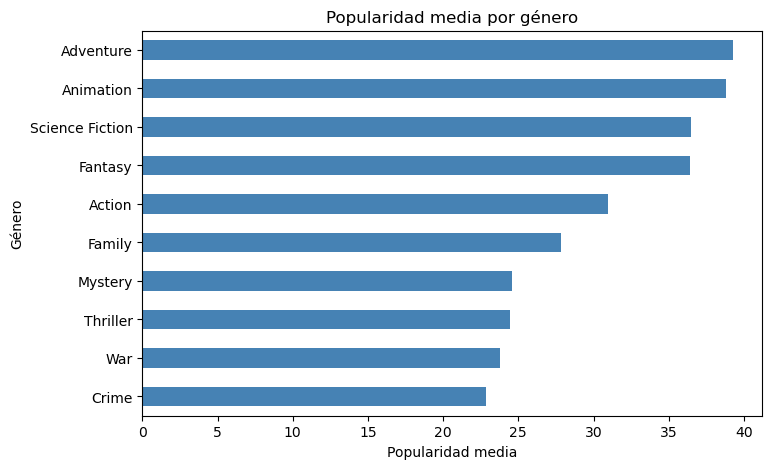

In [136]:
df_genres.groupby("genres")["popularity"].mean() \
    .sort_values(ascending=False) \
    .head(10) \
    .sort_values() \
    .plot(
        kind="barh",
        figsize=(8,5),
        color="steelblue",
        title="Popularidad media por género"
    )

plt.xlabel("Popularidad media")
plt.ylabel("Género")
plt.show()

In [ ]:
# 4.4 Presupuesto medio por género (hipotesis 2)
pd.options.display.float_format = '{:,.0f}'.format
df_genres.groupby("genres")["budget"].mean().sort_values(ascending=False)

genres
Animation         66,465,902
Adventure         66,326,861
Fantasy           63,560,605
Science Fiction   51,865,551
Action            51,510,751
Family            50,719,512
War               35,282,457
Thriller          31,968,207
Mystery           30,744,487
History           29,903,467
Crime             27,849,808
Western           27,078,702
Comedy            25,313,421
Drama             20,680,798
Romance           20,311,362
Music             15,907,948
Horror            14,574,031
Documentary        2,693,970
TV Movie           1,150,000
Foreign              658,088
Name: budget, dtype: float64

**Presupuesto vs género**

Los géneros con mayor presupuesto son:

- Animation → 66M  
- Adventure → 66M  
- Fantasy → 63M  
- Sci-Fi → 51M  
- Action → 51M  

Los más bajos:

- Foreign → 0.6M  
- TV Movie → 1.1M  
- Documentary → 2.6M  


**Interpretación** 

Insight 1: los géneros más caros son los más “visuales” y de gran producción como Animación, Aventura, Ciencia ficción y Fantasía. Por tanto, lo más caro coincide con lo más popular. 


Insight 2: Los géneros baratos son contenido más pequeño o menos comercial como Documentales, TV movies  o Cine extranjero  


Insight 3: Comparando géneros con presupuesto mayor y los mejor valorados, esto no coincide ya que los que tienen mejores ratings son las que tienen menor presupuesto (Drama, history, War). Por tanto, más presupuesto ≠ mejor valoración

Porque:

- Animation / Adventure → mucho dinero  
- pero no necesariamente son los mejor valorados  


**Conexión con hipótesis 2**

**El presupuesto influye más en popularidad que en valoración**

- sí influye en qué tipo de películas se hacen  
- sí influye en visibilidad  
- pero no garantiza calidad (lo veremos después)  


**Conclusión** 
Los géneros con mayor presupuesto son aquellos relacionados con grandes producciones como animación, aventura y ciencia ficción. En cambio, documentales o TV movies tienen presupuestos mucho más bajos. Esto sugiere que los generos con mayor presupuesto tienden a ser también los más populares.

In [ ]:
# 4.5 popularidad vs valoracion (hipotesis 3)
# Las películas más populares también están mejor valoradas?

# Para contexto, relación media por género
df_exploded = df.explode("genres")

genre_popularity_rating = (
    df_exploded.groupby("genres")[["popularity", "vote_average"]]
    .mean()
    .round(2)
)

genre_popularity_rating.sort_values(
    by="popularity",
    ascending=False
)

,popularity,vote_average
genres,,
Adventure,39.27,6.16
Animation,38.81,6.34
Science Fiction,36.45,6.01
Fantasy,36.39,6.10
Action,30.94,5.99
Family,27.83,6.03
Mystery,24.59,6.18
Thriller,24.46,6.01
War,23.78,6.71


In [123]:
# Correlación entre popularidad y valoración
df[["popularity", "vote_average"]].corr()

,popularity,vote_average
popularity,1.00,0.27
vote_average,0.27,1.00


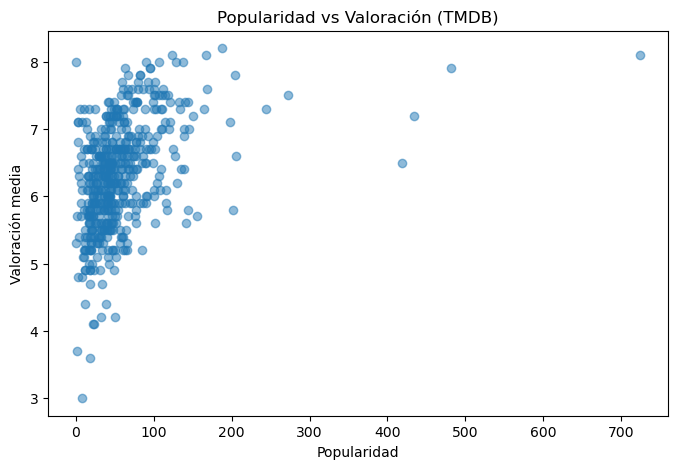

In [141]:
# Visualización: Popularidad vs valoración
plt.figure(figsize=(8,5))

plt.scatter(df_final["popularity"], df_final["vote_average"], alpha=0.5)

plt.title("Popularidad vs Valoración (TMDB)")
plt.xlabel("Popularidad")
plt.ylabel("Valoración media")
plt.show()

**Insight**

Para analizar si las películas más populares también son las mejor valoradas, se calculó la correlación entre las variables `popularity` y `vote_average`.

Teniendo en cuenta que la correlación es una medida estadística que indica cómo de relacionadas están dos variables:
- valores cercanos a `1` indican una relación fuerte positiva
- valores cercanos a `0` indican poca o ninguna relación
- valores negativos indican relación inversa

En este caso, la correlación obtenida fue de `0.27`, lo que representa una relación positiva débil.

Esto significa que las películas más populares tienden, en algunos casos, a recibir mejores valoraciones, pero la relación no es lo suficientemente fuerte como para afirmar que una película popular será necesariamente mejor valorada.

Además, al comparar géneros, se observa que películas de acción, aventura o ciencia ficción destacan en popularidad, mientras que géneros como drama, historia o guerra suelen obtener valoraciones medias más altas.

**Conclusión**

La relación entre popularidad y valoración es débil, por lo que una película muy popular no necesariamente será la mejor valorada.


In [67]:
df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'title', 'vote_average', 'vote_count'],
      dtype='object')

In [71]:
# 5. OMDB API - datos reales de la industria del cine
api_key = input("API key de OMDb: ")


In [75]:
# 5.1 Prueba API
get_imdb_info("Avatar", api_key)

{'imdb_rating': '7.9',
 'imdb_votes': '1,486,308',
 'director': 'James Cameron',
 'year': '2009'}

In [86]:
# 5.3 muestra 500 y llamadas API
df_sample = df.drop_duplicates(subset="title").head(500).copy()

df_api = df_sample["title"].apply(lambda x: get_imdb_info(x, api_key)).apply(pd.Series)

df_api["title"] = df_sample["title"].values

df_api.head()

,imdb_rating,imdb_votes,director,year,title
0,7.9,"1,486,308",James Cameron,2009,Avatar
1,7.2,"743,246",Gore Verbinski,2007,Pirates of the Caribbean: At World's End
2,6.8,"493,010",Sam Mendes,2015,Spectre
3,8.4,"1,990,749",Christopher Nolan,2012,The Dark Knight Rises
4,6.6,"294,974",Andrew Stanton,2012,John Carter


In [87]:
# 5.4 Guardamos datos API OMDB localmente en csv
df_api.to_csv("omdb_cache_500.csv", index=False) 

In [ ]:
# 5.5 unimos/merge

ddf_api = pd.read_csv("omdb_cache_500.csv")

df_sample = df.drop_duplicates(subset="title").head(500).copy()

df_sample["title"] = df_sample["title"].str.strip() # limpiar titulos para evitar errores de mer me lo pone en problems de VS
df_api["title"] = df_api["title"].str.strip()

df_final = df_sample.merge(df_api, on="title", how="left")

df_final.head()

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,...,runtime,spoken_languages,status,title,vote_average,vote_count,imdb_rating,imdb_votes,director,year
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",...,162,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Avatar,7,11800,7.9,"1,486,308",James Cameron,2009
1,300000000,"[Adventure, Fantasy, Action]",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",...,169,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Pirates of the Caribbean: At World's End,7,4500,7.2,"743,246",Gore Verbinski,2007
2,245000000,"[Action, Adventure, Crime]",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",...,148,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,Spectre,6,4466,6.8,"493,010",Sam Mendes,2015
3,250000000,"[Action, Crime, Drama, Thriller]",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",...,165,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Dark Knight Rises,8,9106,8.4,"1,990,749",Christopher Nolan,2012
4,260000000,"[Action, Adventure, Science Fiction]",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",44,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",...,132,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,John Carter,6,2124,6.6,"294,974",Andrew Stanton,2012


In [125]:
# 5.6 Limpieza OMDB
df_final["imdb_rating"] = pd.to_numeric(df_final["imdb_rating"], errors="coerce")
df_final["vote_average"] = pd.to_numeric(df_final["vote_average"], errors="coerce")

df_final["imdb_votes"] = (
    df_final["imdb_votes"].str.replace(",", "", regex=False)
)

df_final["imdb_votes"] = pd.to_numeric(df_final["imdb_votes"], errors="coerce")

In [126]:
df_final[["title", "vote_average", "imdb_rating"]].head(10)

,title,vote_average,imdb_rating
0,Avatar,7.20,7.90
1,Pirates of the Caribbean: At World's End,6.90,7.20
2,Spectre,6.30,6.80
3,The Dark Knight Rises,7.60,8.40
4,John Carter,6.10,6.60
5,Spider-Man 3,5.90,6.30
6,Tangled,7.40,7.70
7,Avengers: Age of Ultron,7.30,7.30
8,Harry Potter and the Half-Blood Prince,7.40,7.60
9,Batman v Superman: Dawn of Justice,5.70,6.40


In [127]:
df_final[["vote_average", "imdb_rating"]].dtypes

vote_average    float64
imdb_rating     float64
dtype: object

In [128]:
# 6. EDA - OMDB vs TMDB
# IMDb vs TMDB pueden dar valoraciones diferentes (para comprobar hipotesis 4)
# 6.1 cómo puntúa TMDB las películas en general (para tener contexto antes de comparar con datos api)

df_final["vote_average"].describe().round(2)


count   500.00
mean      6.32
std       0.81
min       3.00
25%       5.80
50%       6.30
75%       6.90
max       8.20
Name: vote_average, dtype: float64

**Interpretación**
- Media: 6.32
- Mediana (50%): 6.30
- Mínimo: 3.0
- Máximo: 8.2
- 75%: 6.9

TMDB tiene distribución bastante centrada ya que la mayoría de películas están entre 5.8 y 6.9, no hay extremos muy grandes y, la media y mediana son casi iguales.

**Conclusión**

TMDB presenta una distribución de valoraciones centrada en torno a 6.3, con la mayoría de películas situadas entre 5.8 y 6.9. Esto indica una escala relativamente equilibrada y sin grandes desviaciones extremas.

In [129]:
# 6.2 cómo puntua OMDb 
df_final["imdb_rating"].describe()


count   490.00
mean      6.63
std       0.98
min       2.30
25%       6.10
50%       6.60
75%       7.30
max       9.10
Name: imdb_rating, dtype: float64

OMDb (imdb_rating):

- Media: 6.63
- Mediana: 6.6
- Mínimo: 2.3
- Máximo: 9.1
- Desviación estandar: 0.99

Comparación OMDb y TMDB (medias)

TMDB → 6.32

IMDb → 6.63

**Interpretación**

OMDb tiende a dar ratings más altos y tiene más variabilidad. En cambio, TMDB es más conservador y estable.

**Conclusión** 

IMDb presenta una media de valoración ligeramente superior a TMDB (6.63 vs 6.32), además de una mayor dispersión en los datos. Esto sugiere que IMDb utiliza una escala más optimista y con mayor variabilidad, mientras que TMDB muestra una distribución más estable y concentrada. En consecuencia, aunque ambas plataformas siguen tendencias similares, sus valores no son directamente equivalentes.



In [ ]:
# 6.3 Diferencia OMDb vs TMDB
# Se mide cúanto más o menos puntúa OMDB (API) respecto TMDB en cada película
df_final["rating_diff"] = df_final["imdb_rating"] - df_final["vote_average"]

df_final[["title", "vote_average", "imdb_rating", "rating_diff"]].head(10)

,title,vote_average,imdb_rating,rating_diff
0,Avatar,7.20,7.90,0.70
1,Pirates of the Caribbean: At World's End,6.90,7.20,0.30
2,Spectre,6.30,6.80,0.50
3,The Dark Knight Rises,7.60,8.40,0.80
4,John Carter,6.10,6.60,0.50
5,Spider-Man 3,5.90,6.30,0.40
6,Tangled,7.40,7.70,0.30
7,Avengers: Age of Ultron,7.30,7.30,0.00
8,Harry Potter and the Half-Blood Prince,7.40,7.60,0.20
9,Batman v Superman: Dawn of Justice,5.70,6.40,0.70


**Interpretación**

- positivo (+) → OMDb puntúa más alto que TMDB
- 0 → ambas coinciden
- negativo (-) → TMDB puntúa más alto (casi no pasa en tu muestra)

**Resultado**
- Avatar → +0.70
- Avengers: Age of Ultron → 0.00
- The Dark Knight Rises → +0.80

OMDb puntúa más alto porque en casi todas las películas hay una diferencia positiva, normalmente entre 0,2 y 0,8. Y en casos muy puntuales como Avengers 0.00 coinciden. 

**Conclusión**

La diferencia entre las valoraciones de OMDb y TMDB muestra un patrón consistente en el que OMDb tiende a puntuar ligeramente más alto en la mayoría de las películas analizadas. Esta diferencia, aunque no extrema, confirma que ambas plataformas no son directamente equivalentes en escala, aunque mantienen tendencias similares en la valoración de las películas.


In [132]:
# 6.4 Distribución de rating_diff
# Para medir cómo de grande es la diferencia de ambas plataformas
df_final["rating_diff"].describe()


count   490.00
mean      0.31
std       0.46
min      -2.10
25%       0.10
50%       0.30
75%       0.50
max       3.30
Name: rating_diff, dtype: float64

**Resultado**

- Media de diferencia: +0.31
- Mediana: +0.30
- Desviación típica: 0.47
- Mínimo: -2.1
- Máximo: +3.3

**Interpretación**

- OMDb puntúa sistemáticamente más alto, tiene la media positiva (+0.31) y la mediana similar refuerza estabilidad del patrón.La mayoría de diferencias están entre 0.1 y 0.5.
- Hay casos aislados (min. -2,10 y max. 3.30) donde OMDB punto mucho más bajo o mucho más alto que TMDB.

**Conclusión**

La diferencia entre las valoraciones de OMDb y TMDB muestra que OMDb tiende a puntuar ligeramente más alto de forma consistente. La mayoría de las diferencias se encuentran entre 0.1 y 0.5, lo que indica que ambas plataformas no utilizan exactamente la misma escala, aunque siguen patrones similares.


In [133]:
# 7. Las películas recientes tienden a ser más populares (hipotesis 5 evolucion temporal)
# 7.1 Popularidad por año

# añadimos columna año
df_final["release_date"] = pd.to_datetime(df_final["release_date"], errors="coerce")

df_final["year"] = df_final["release_date"].dt.year

df_final[["title", "release_date", "year"]].head(10)

,title,release_date,year
0,Avatar,2009-12-10,2009
1,Pirates of the Caribbean: At World's End,2007-05-19,2007
2,Spectre,2015-10-26,2015
3,The Dark Knight Rises,2012-07-16,2012
4,John Carter,2012-03-07,2012
5,Spider-Man 3,2007-05-01,2007
6,Tangled,2010-11-24,2010
7,Avengers: Age of Ultron,2015-04-22,2015
8,Harry Potter and the Half-Blood Prince,2009-07-07,2009
9,Batman v Superman: Dawn of Justice,2016-03-23,2016


In [134]:
df_final.groupby("year")["popularity"].mean().sort_index()

year
1979     5.16
1982    22.73
1990    43.13
1991   101.74
1992    59.11
1993    32.04
1994    64.59
1995    37.94
1996    39.36
1997    40.83
1998    28.19
1999    34.52
2000    32.15
2001    46.17
2002    48.47
2003    53.58
2004    44.40
2005    40.65
2006    43.13
2007    51.73
2008    54.37
2009    49.07
2010    46.90
2011    45.70
2012    69.46
2013    61.44
2014   134.76
2015   106.08
2016    72.25
Name: popularity, dtype: float64

**Popularidad vs Año**

Se observa la media de popularidad por año desde 1979 hasta 2016.


- Insight 1 — tendencia general ascendente. A partir de los años 2000 la popularidad es más alta que en los 80–90 (picos muy fuertes en 2014–2015). Ejemplos:

    - 2014 → 134 (muy alto)
    - 2015 → 106
    - 2016 → 72

- Insight 2 — años antiguos = baja popularidad (menos visible)
    - 1979 → 5
    - 1982 → 22
    - 1990 → 43

- Insight 3 — el crecimiento no es lineal, no sube de forma constante: hay años con bajadas y hay picos muy fuertes (ej. 1991, 2014).

**Conclusión**

El análisis de la popularidad media por año de estreno muestra una tendencia general en la que las películas más recientes tienden a presentar valores de popularidad más altos en comparación con películas más antiguas.

En los años 80 y 90, la popularidad media es más baja y más irregular, mientras que a partir de los años 2000 se observa un aumento progresivo. En la última década (2010 en adelante) se alcanzan los valores más altos, con algunos picos muy significativos en determinados años.

Sin embargo, esta tendencia no es completamente lineal ni uniforme. Existen años concretos con valores muy altos de popularidad, lo que sugiere que el resultado está influido por películas específicas de gran impacto, como grandes franquicias o producciones muy mediáticas.

Por tanto, este comportamiento no se debe únicamente al paso del tiempo, sino también a factores como el consumo digital y la exposición mediática de ciertas películas.

Se puede decir que la hipótesis 5 se cumple parcialmente: las películas recientes tienden a ser más populares, pero este efecto está condicionado por factores externos y no por el año en sí de forma aislada.



<Axes: title={'center': 'IMDb vs TMDB (media)'}>

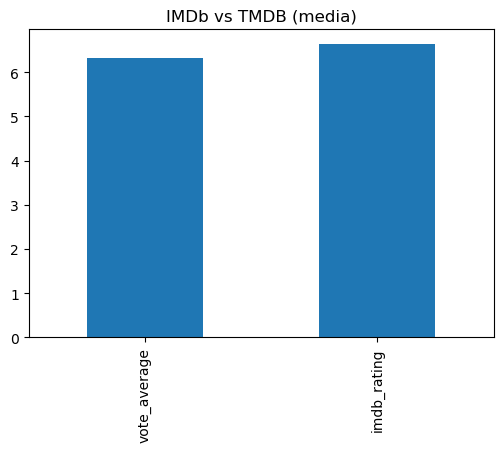

In [118]:
df_final[["vote_average", "imdb_rating"]].mean().plot(kind="bar", figsize=(6,4), title="IMDb vs TMDB (media)")